In [1]:
import destruction_models as models
from tensorflow.keras import callbacks, metrics
from tensorflow.keras.utils import Sequence
from destruction_utilities import *
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score, precision_score, recall_score

from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC


In [2]:
CITY = 'aleppo'
BATCH_SIZE = 32
TILE_SIZE = [64,64]

auc = AUC(
    num_thresholds=200,
    curve='ROC',
    name="auc"
)

Metal device set to: Apple M1


2022-07-14 21:41:08.223962: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-14 21:41:08.224143: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
class SiameseGenerator(Sequence):
    def __init__(self, images, labels, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.labels = labels
        self.batch_size = batch_size
        self.tuple_pairs = make_tuple_pair(self.images_t0.shape[0], self.batch_size)
        np.random.shuffle(self.tuple_pairs)
   
   
    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
        index_range = self.tuple_pairs[index]
        indices = np.arange(0,32)
        np.random.shuffle(indices)

        X_t0 = self.images_t0[index_range[0]:index_range[1]][indices]
        X_t1 = self.images_tt[index_range[0]:index_range[1]][indices]
        y = self.labels[index_range[0]:index_range[1]][indices]
        
        alpha = random.choice(np.linspace(0.85, 1.4))
        
        return {'images_t0':X_t0 *alpha, 'images_tt':X_t1 *alpha}, y

    def augment(self, X):
#         # Horizontal and vertical flip
#         flipping_funcs = [
#             lambda image: image,
#             lambda image: np.fliplr(image),
#             lambda image: np.flipud(image),
#             lambda image: np.flipud(np.fliplr(image))
#         ]
#         func = random.choice(flipping_funcs)
#         X = func(X)
        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha

        return X

In [5]:
def run_model(train_images, train_labels, valid_images, valid_labels, run_id = 1):
    train_gen = SiameseGenerator((train_images[0], train_images[1]), train_labels)
    valid_gen = SiameseGenerator((valid_images[0], valid_images[1]), valid_labels)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'../models/{CITY}/snn/run_{i}/', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([16,32])
    dropout = random.choice(np.linspace(0.1, 0.2))
    epochs = random.choice(np.arange(70,100))
    units = random.choice([32])
    lr = random.choice([0.003, 0.01, 0.03])

    args_encode  = dict(filters=filters, dropout=dropout) # ! Check parameters before run
    args_dense  = dict(units=units, dropout=dropout) # ! Check parameters before run

    parameters = f'filters={filters}, \ndropout={np.round(dropout, 4)}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
#     model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3), args_encode=args_encode, args_dense=args_dense)
    model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3),  args_encode=dict(filters=8, dropout=0), args_dense=dict(units=16, dropout=0))
   
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy',metrics.AUC(num_thresholds=200, curve='ROC', name='auc')])
    model.summary()
    

    # Train model on dataset
    history = model.fit_generator(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=1,
        callbacks=training_callbacks
    )
    
    return model, history, parameters

In [6]:
def plot_training(H, P, ts, plotPath):
	# construct a plot that plots and saves the training history
	plt.style.use("ggplot")
	plt.figure()
	plt.plot(H.history["accuracy"], label="train_accuracy")
	plt.plot(H.history["val_accuracy"], label="val_accuracy")
	plt.plot(H.history["auc"], label="train_auc")
	plt.plot(H.history["val_auc"], label="val_auc")
	plt.title(f"Training Accuracy and AUC")
	plt.suptitle(f"City = {CITY}") 
	plt.xlabel("Epoch #")
	plt.ylabel("AUC")
	plt.text(0.65, 0.18, P + f"\nmax(val_auc)={np.round(np.max(H.history['val_auc']), 4)}\ncode={ts}", fontsize=8, transform=plt.gcf().transFigure)
	plt.legend(loc="lower left")
	plt.savefig(plotPath)

filters=16, 
dropout=0.1408, 
epochs=71, 
units=32, 
learning_rate=0.03
Model: "siamese_convolutional_network"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 images_t0 (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 images_tt (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 encoder (Functional)           (None, 640)          23736       ['images_t0[0][0]',             

/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_90530/2620014195.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/71


2022-07-14 21:41:09.080858: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-07-14 21:41:11.342572: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


6365/6365 [==============================] - ETA: 0s - loss: 0.7014 - accuracy: 0.4952 - auc: 0.4958

...

Epoch 1/87


2022-07-15 19:53:08.267587: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


6365/6365 [==============================] - ETA: 0s - loss: 0.7025 - accuracy: 0.4982 - auc: 0.4975

2022-07-15 20:15:59.285273: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: ../models/aleppo/snn/run_4/assets
6365/6365 [==============================] - 1436s 225ms/step - loss: 0.7025 - accuracy: 0.4982 - auc: 0.4975 - val_loss: 2.1864 - val_accuracy: 0.9587 - val_auc: 0.3084
Epoch 2/87
6365/6365 [==============================] - 1421s 223ms/step - loss: 0.7015 - accuracy: 0.5071 - auc: 0.5030 - val_loss: 0.6532 - val_accuracy: 0.9630 - val_auc: 0.3464
Epoch 3/87
6365/6365 [==============================] - 1418s 223ms/step - loss: 0.7005 - accuracy: 0.5000 - auc: 0.4990 - val_loss: 41188.5195 - val_accuracy: 0.0468 - val_auc: 0.4066
Epoch 4/87
6365/6365 [==============================] - 1419s 223ms/step - loss: 0.6994 - accuracy: 0.5028 - auc: 0.5049 - val_loss: 725.3452 - val_accuracy: 0.0435 - val_auc: 0.5994
Epoch 5/87
6365/6365 [==============================] - 1428s 224ms/step - loss: 0.7012 - accuracy: 0.5006 - auc: 0.4975 - val_loss: 9.0195 - val_accuracy: 0.9573 - val_auc: 0.5237
Epoch 6/87
6365/6365 [=========

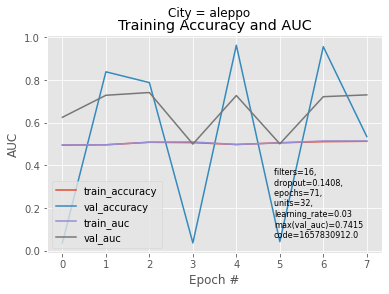

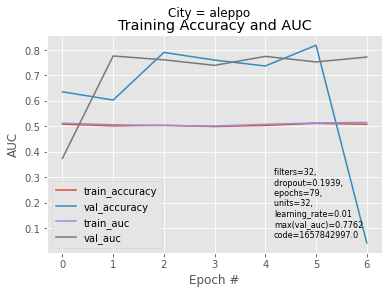

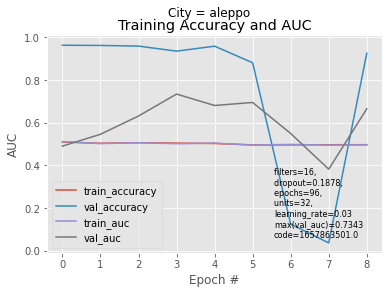

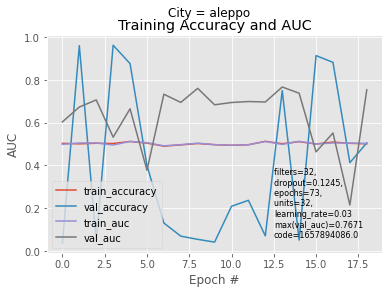

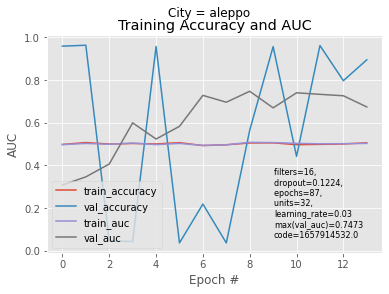

In [7]:
for i in range(0,5):
    m = run_model((train_images_t0, train_images_tt), train_labels, (valid_images_t0, valid_images_tt), valid_labels, run_id=i)
    model = m[0]
    history = m[1]
    parameters = m[2]
    print("Model optimization complete..\n\n")
    ts = str(np.round(time.time()))
    with open(f'../models/{CITY}_SNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
    
    model.save(f'../models/{CITY}_SNN_RUN{i}_{ts}', save_format="h5")
    plot_training(history, parameters, ts, f'../figures/{CITY}_SNN_RUN{i}_{ts}.png')
    
    with open('../models/run_parameters.txt', "a") as file:
        file.write(f'{CITY}_SNN_RUN{i}_{ts}: \n \t{parameters}\n')
      


2022-07-16 01:34:01.165125: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1 
Test Set AUC Score for the ROC Curve: 0.6077890573105529


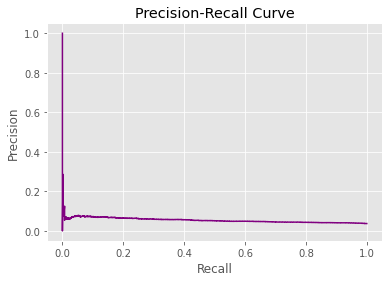

2022-07-16 01:34:51.849639: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2 
Test Set AUC Score for the ROC Curve: 0.597768503696928


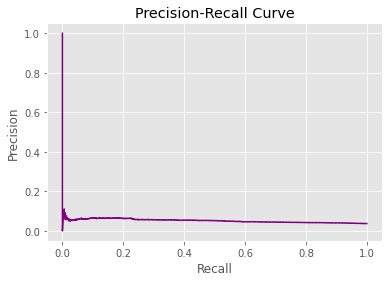

2022-07-16 01:35:43.171233: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3 
Test Set AUC Score for the ROC Curve: 0.6002013709668638


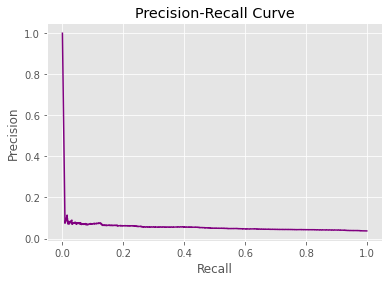

2022-07-16 01:36:35.705569: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4 
Test Set AUC Score for the ROC Curve: 0.5878503370248168


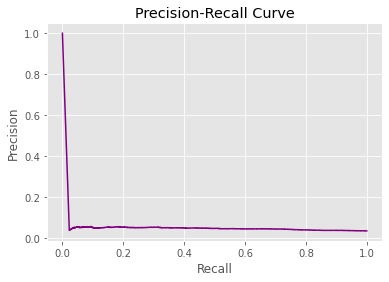

2022-07-16 01:37:27.226462: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 5 
Test Set AUC Score for the ROC Curve: 0.6162687977088847


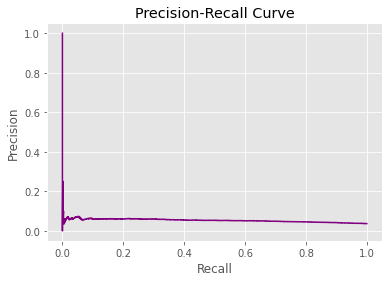

In [8]:
class SiameseTestGenerator(Sequence):
    def __init__(self, images, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.batch_size = batch_size

    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
        if(index == self.__len__()-1):
            X_t0 = self.images_t0[index*self.batch_size:len(self.images_t0)]
            X_tt = self.images_tt[index*self.batch_size:len(self.images_t0)]
        else:
            X_t0 = self.images_t0[index*self.batch_size:(index+1)*self.batch_size]          
            X_tt = self.images_tt[index*self.batch_size:(index+1)*self.batch_size]          
    
        
        return {'images_t0':X_t0, 'images_tt':X_tt}



for i in range(0, 5):
    model_path = f'../models/{CITY}/snn/run_{i}'
    best_model = load_model(model_path, custom_objects={'auc':metrics.AUC(num_thresholds=200, curve='ROC', name='auc')})
    test_generator = SiameseTestGenerator((test_images_t0, test_images_tt))
    yhat_proba, y = np.squeeze(best_model.predict(test_generator)[0:test_labels[:].shape[0]]), np.squeeze(test_labels[:])
    roc_auc_test = roc_auc_score(y, yhat_proba)
    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)


    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i+1} \nTest Set AUC Score for the ROC Curve: {roc_auc_test}' )
    #display plot
    plt.show()

```
filters=32, dropout=0.13163265306122449, epochs=77, units=32, learning_rate=0.01
filters=32, dropout=0.18571428571428572, epochs=88, units=48, learning_rate=0.003

Upto 88
filters=32, 
dropout=0.1939, 
epochs=77, 
units=32, 
learning_rate=0.012


```